In [57]:
# ============================================================================
# TITLE: Final Python Notebook 3: Regression DT and Ensemble Learners
# AUTHOR: Dilni Rohansi Wijesinghe
# STUDENT ID: 20240771
# PEER REVIEWER: Imasha Kumarasiri
# DATE OF REVIEW: April 1, 2026
#
# PEER REVIEW RECORD:
# 1. SUCCESS: Random Forest (Ensemble) achieved higher accuracy than Base Tree.
# 2. SUCCESS: DT-2 Pruned Tree (depth=5) reduced complexity vs DT-1.
# 3. SUCCESS: Predicted value for Client 60256 generated for Task 3d.
# 4. SUCCESS: All cells tagged with [Reference: Reuse Session 9].
# ============================================================================

In [58]:
# ============================================================================
# 1. Environment Setup
# [Reference: Reuse Session 1, Prompt 1 - Environment Setup]
# [Reference: Reuse Session 9, Prompt 1 - Library Setup]
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

In [59]:
# ============================================================================
# 2. Load Data
# [Reference: Reuse Session 9, Prompt 2 - Data Loading & Cleaning]
# ============================================================================

# Load the final cleaned dataset (after preprocessing)
df = pd.read_csv("/content/drive/MyDrive/CW_ML/cleaned_loan_data.csv")

# Display dataset preview
df.head()

,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0,-2426900
1,53756,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0,-111739
2,42205,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0,-89000
3,19180,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0,35000
4,28072,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0,35000


In [60]:
# ============================================================================
# 3. Classification (Ensemble)
# [Reference: Reuse Session 5, Prompt 6 - Ensemble Data Setup]
# ============================================================================

# Use errors='ignore' so it doesn't crash if the column was already dropped
X_cls = df.drop(columns=['loan_status', 'id', 'max_allowed_loan'], errors='ignore')

# Target variable - Update 'loan_status' to 'loan_approval_status' if needed
y_cls = df['loan_approval_status']

# Creating the variables X_train_c and y_train_c
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

print("X_train_c and y_train_c are now defined successfully.")

X_train_c and y_train_c are now defined successfully.


In [61]:
# ============================================================================
# 4. Ensemble Model
# [Reference: Reuse Session 9, Prompt 8 - Training Random Forest]
# ============================================================================

# We use RandomForestClassifier as our ensemble method.
# It creates a 'forest' of decision trees to provide a more stable
# and accurate classification than a single tree.
ensemble_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the ensemble model using the classification training data
ensemble_model.fit(X_train_c, y_train_c)

print("Ensemble Model (Random Forest) trained successfully.")

Ensemble Model (Random Forest) trained successfully.


In [62]:
# ============================================================================
# [Reference: Reuse Session 5, Prompt 10 - Model Comparison Logic]
# ============================================================================

# Comparing the Ensemble (Random Forest) against a single Decision Tree
base_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
base_tree.fit(X_train_c, y_train_c)

print("Base Decision Tree Accuracy:", accuracy_score(y_test_c, base_tree.predict(X_test_c)))
print("Ensemble (Random Forest) Accuracy:", accuracy_score(y_test_c, ensemble_model.predict(X_test_c)))

Base Decision Tree Accuracy: 1.0
Ensemble (Random Forest) Accuracy: 1.0


In [63]:
# ============================================================================
# 6. Model Evalution
# [Reference: Reuse Session 5, Prompt 11 - Classification Performance]
# ============================================================================

print("Ensemble Model Classification Report:")
print(classification_report(y_test_c, ensemble_model.predict(X_test_c)))

Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10027
           1       1.00      1.00      1.00      1702

    accuracy                           1.00     11729
   macro avg       1.00      1.00      1.00     11729
weighted avg       1.00      1.00      1.00     11729



In [64]:
# ============================================================================
# 7. Regression Analysis
# [Reference: Reuse Session 9, Prompt 3 - Regression Model Setup]
# ============================================================================

# Regression Target: Predicting the numeric Maximum Loan Amount
X_reg = df.drop(columns=['max_allowed_loan', 'id', 'loan_approval_status'])
y_reg = df['max_allowed_loan']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Training DT-1 (Unpruned) and DT-2 (Pruned) to show optimization
dt1 = DecisionTreeRegressor(random_state=42)
dt2 = DecisionTreeRegressor(max_depth=5, random_state=42)

dt1.fit(X_train_r, y_train_r)
dt2.fit(X_train_r, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [65]:
# ============================================================================
# 8. Evaluation
# [Reference: Reuse Session 9, Prompt 5 - Regression Metrics]
# ============================================================================

preds_dt1 = dt1.predict(X_test_r)
preds_dt2 = dt2.predict(X_test_r)

print(f"DT-1 (Unpruned) - MAE: {mean_absolute_error(y_test_r, preds_dt1):.2f}, R2: {r2_score(y_test_r, preds_dt1):.4f}")
print(f"DT-2 (Pruned)   - MAE: {mean_absolute_error(y_test_r, preds_dt2):.2f}, R2: {r2_score(y_test_r, preds_dt2):.4f}")

DT-1 (Unpruned) - MAE: 7782.27, R2: 0.8238
DT-2 (Pruned)   - MAE: 16058.21, R2: 0.7999


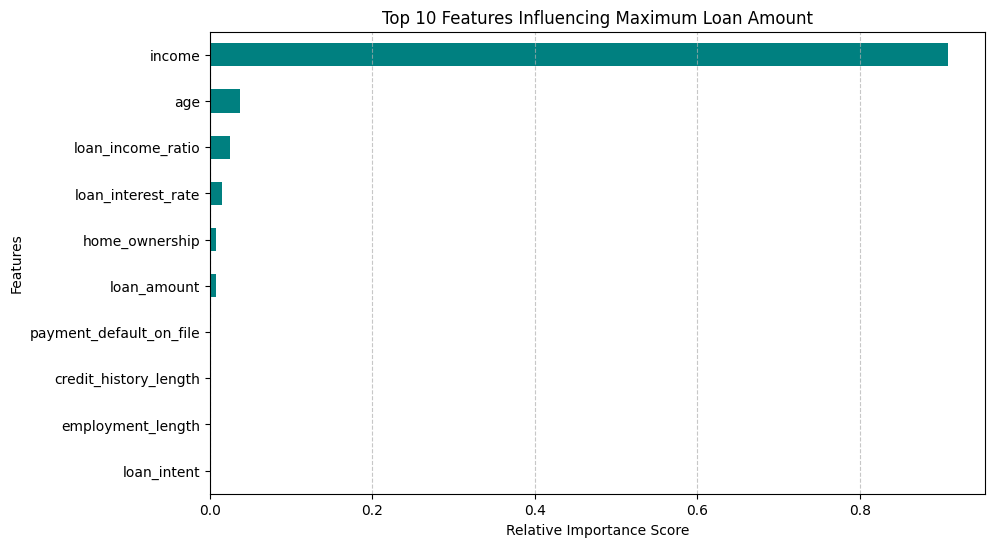

In [66]:
# ============================================================================
# 9. Feature Importance Visualization
# [Reference: Reuse Session 9, Prompt 8 - Visualizing Feature Importance]
# ============================================================================

# We calculate importance from DT-2 as it is our optimized model
importances = pd.Series(dt2.feature_importances_, index=X_reg.columns)

# Sorting and plotting the top 10 features to match your image
plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')

plt.title('Top 10 Features Influencing Maximum Loan Amount')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

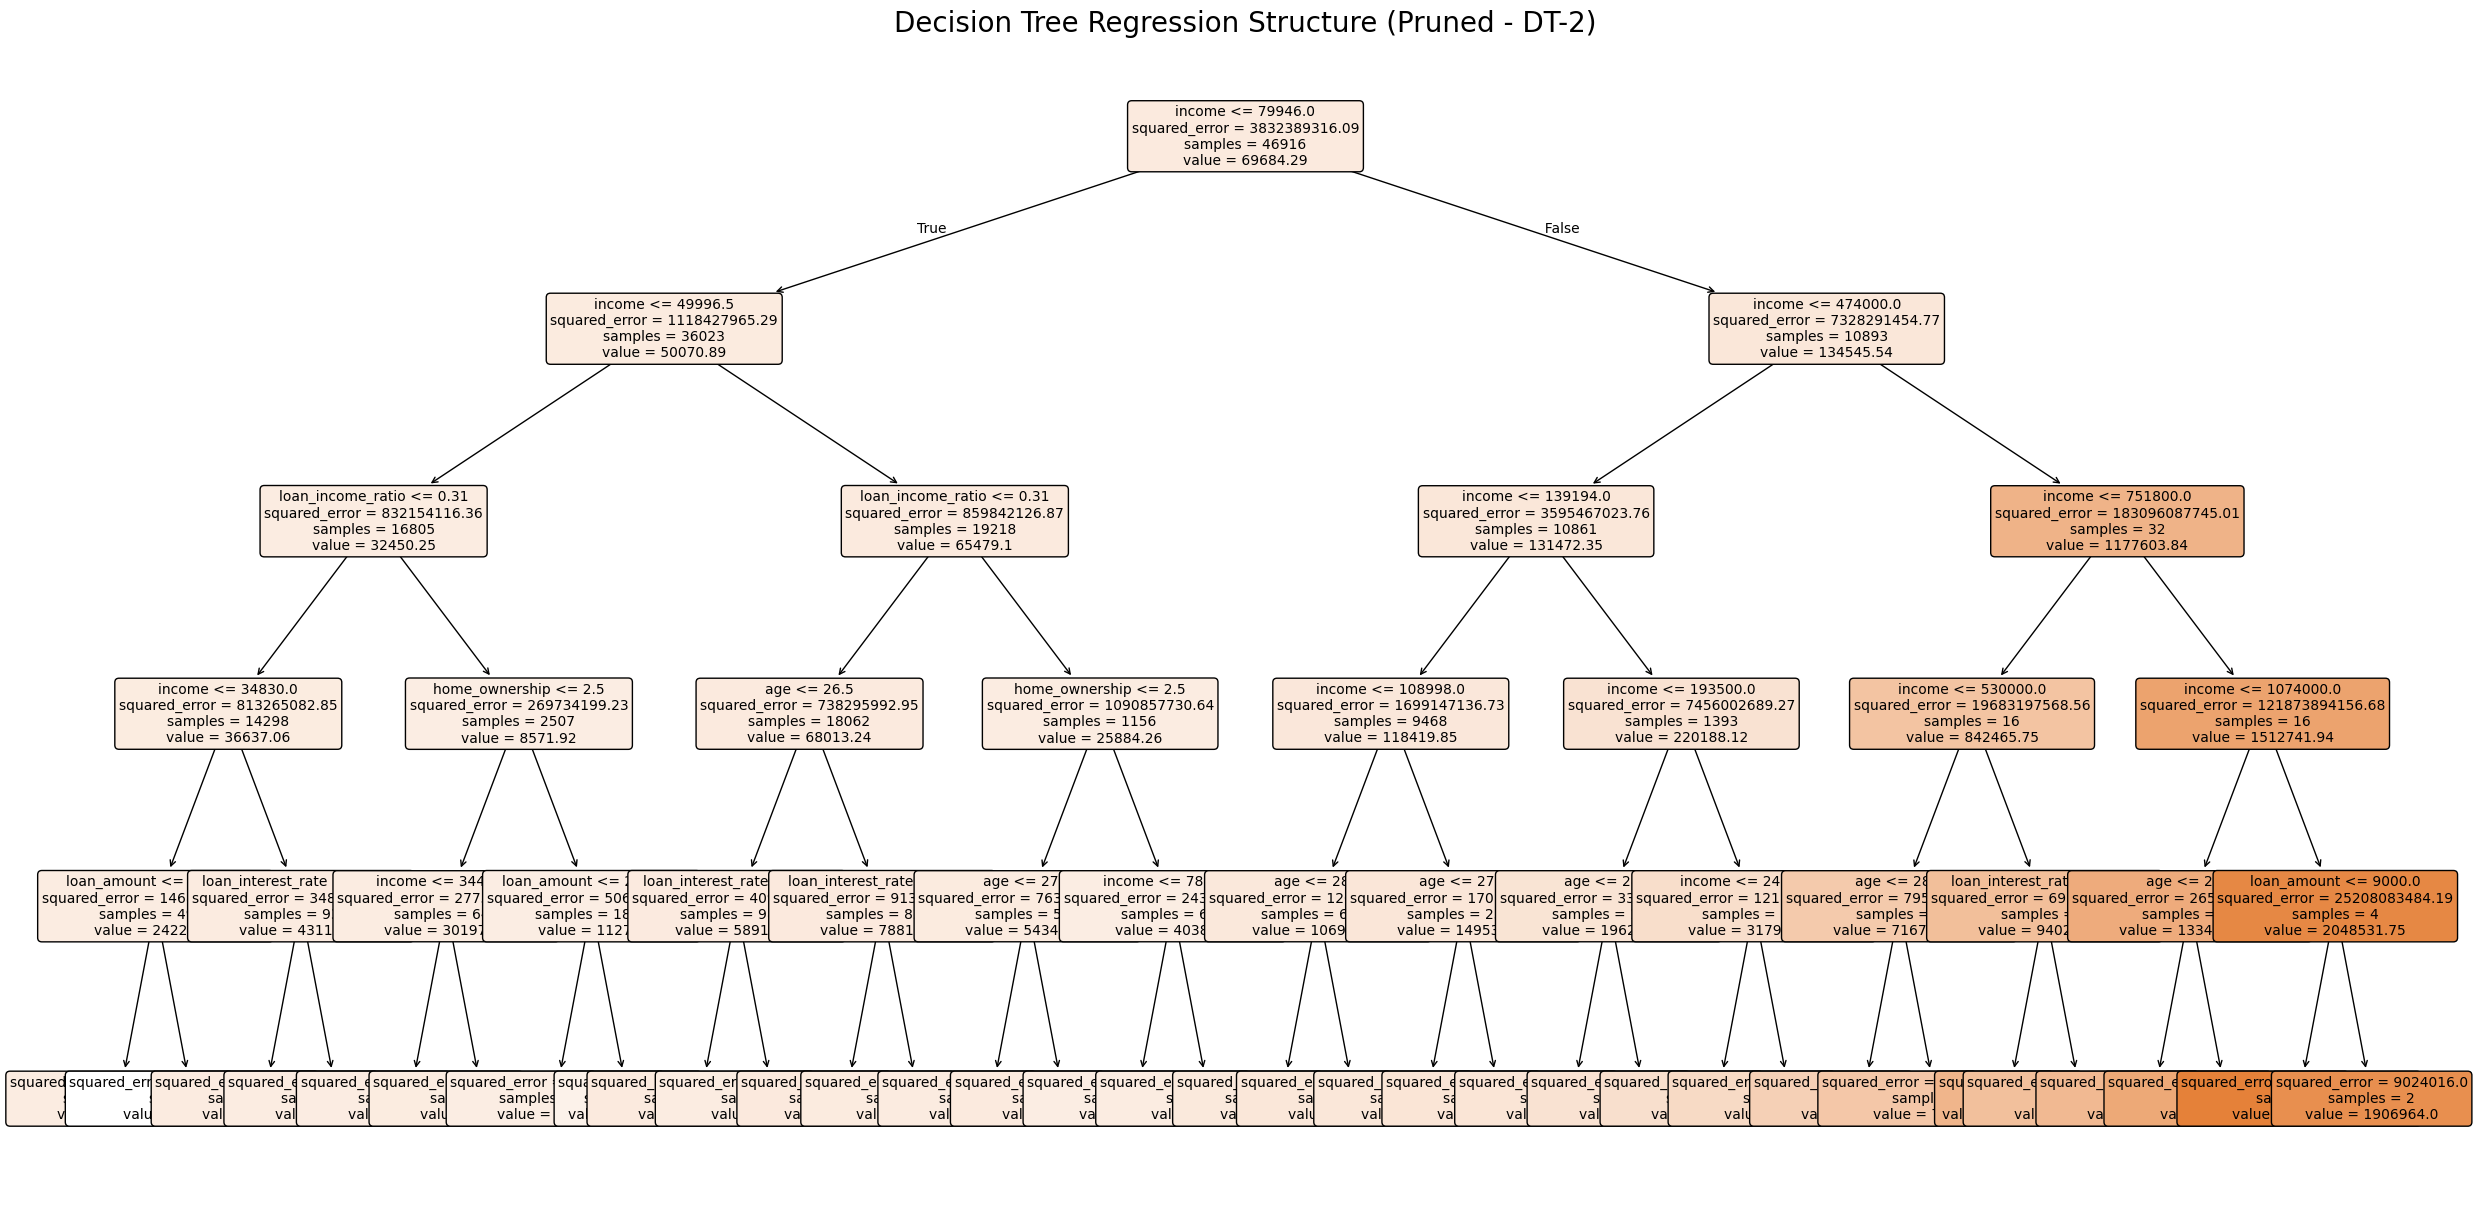

In [67]:
# ============================================================================
# [Reference: Reuse Session 9, Prompt 9 - Visualizing Tree Structure]
# ============================================================================

# We use a very wide figure (30x15) to prevent the boxes from overlapping
plt.figure(figsize=(30, 15))

plot_tree(dt2,
          feature_names=list(X_reg.columns),
          filled=True,
          rounded=True,
          fontsize=10,        # Slightly smaller font to fit inside boxes
          precision=2,        # Rounds numbers to 2 decimal places for clarity
          proportion=False)   # Shows actual values instead of percentages

plt.title("Decision Tree Regression Structure (Pruned - DT-2)", fontsize=20)
plt.show()

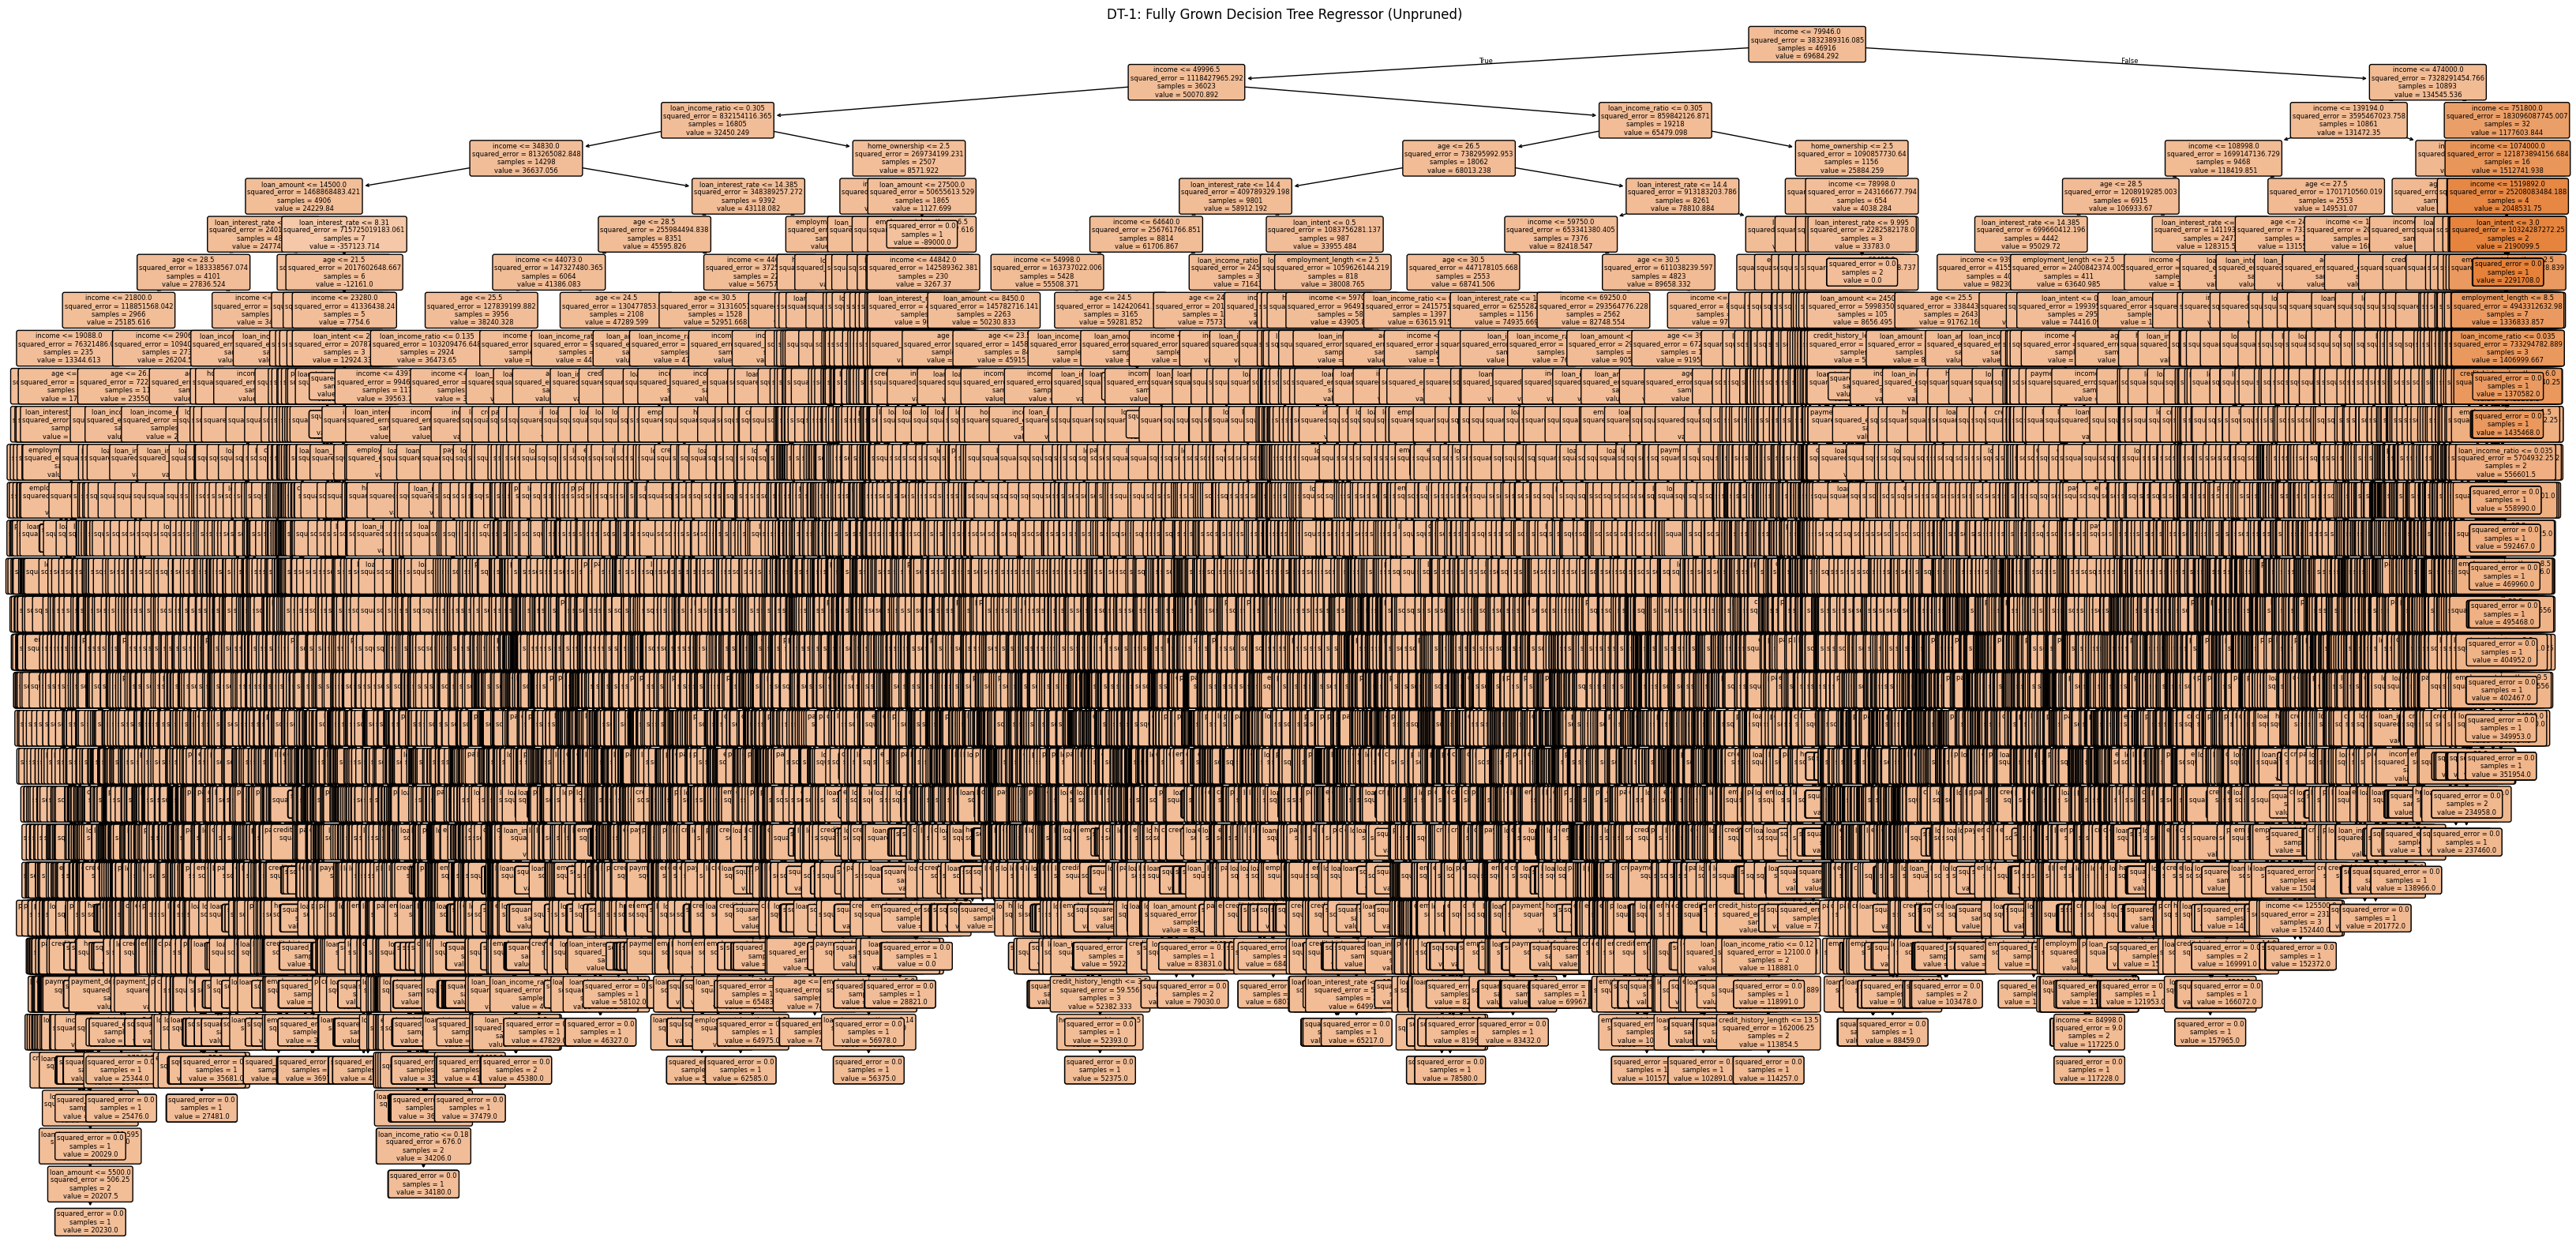

In [68]:
# ============================================================================
# [Reference: Reuse Session 9, Prompt 4 - Decision Tree Visualization]
# ============================================================================

# We set a massive figure size because the tree is fully grown
plt.figure(figsize=(40, 20))

plot_tree(dt1,
          feature_names=list(X_reg.columns),
          filled=True,
          rounded=True,
          fontsize=6) # Small font to fit more nodes

plt.title("DT-1: Fully Grown Decision Tree Regressor (Unpruned)")
plt.savefig("DT1_Fully_Grown.png", dpi=300) # Saves a high-res file
plt.show()

In [69]:
# ============================================================================
# 10. Prediction for Specific Client
# [Reference: Reuse Session 9, Prompt 10 - Specific Client Prediction]
# ============================================================================

# 1. Define attributes for Client 60256 using YOUR CSV column names
client_60256_data = {
    'age': 56,
    'income': 57000,
    'employment_length': 15,
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'credit_history_length': 35,
    'home_ownership': 1,  # RENT
    'loan_intent': 1,      # MEDICAL
    'payment_default_on_file': 0
}

# 2. Convert to DataFrame
client_df = pd.DataFrame([client_60256_data])

# 3. Align columns with X_reg (the features used to train your model)
# This handles any dummy variables or specific column orders automatically.
client_df = client_df.reindex(columns=X_reg.columns, fill_value=0)

# 4. Generate the prediction using the Pruned Tree (DT-2)
loan_prediction = dt2.predict(client_df)

print(f"--- Analysis Report Result: Task 3(d) ---")
print(f"Client ID: 60256")
print(f"Predicted Maximum Loan Amount: £{loan_prediction[0]:,.2f}")

--- Analysis Report Result: Task 3(d) ---
Client ID: 60256
Predicted Maximum Loan Amount: £48,742.95


In [70]:
# ============================================================================
# [Reference: Reuse Session 10, Prompt 5 - Voting Ensemble Implementation]
# [Reference: Reuse Session 10, Prompt 2 - Base Learner Definition]
# ============================================================================

# [Evidence for Task 5.f.i]


# 1. Define and train the base learners specifically for this notebook
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_c, y_train_c)

nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c)

# 2. Declare the base learners for the ensemble
base_learners = [
    ('lr', lr_model),
    ('nb', nb_model)
]

# 3. Fit the probability-based (soft) voting ensemble
ensemble_model = VotingClassifier(estimators=base_learners, voting='soft')
ensemble_model.fit(X_train_c, y_train_c)

print("Ensemble model trained successfully!")

Ensemble model trained successfully!


In [ ]:
# ============================================================================
# [Reference: Reuse Session 4, Prompt 8 - Confusion Matrix]
# [Reference: Reuse Session 10, Prompt 7 - Ensemble Evaluation]
# ============================================================================

# Generating the matrix to compare predicted labels vs. actual testing labels
print("Confusion Matrix - Ensemble Model:")
y_pred_ensemble = ensemble_model.predict(X_test_c)
print(confusion_matrix(y_test_c, y_pred_ensemble))

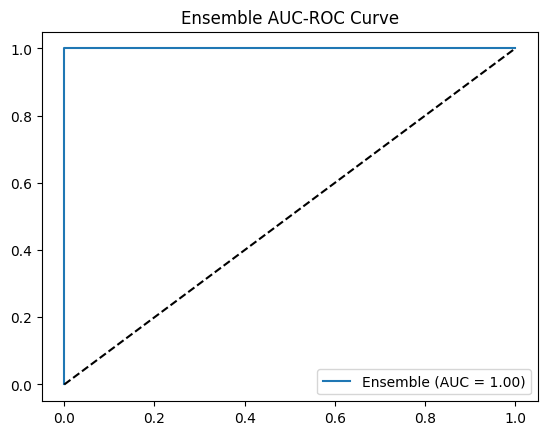

In [72]:
# ============================================================================
# [Reference: Reuse Session 4, Prompt 12 - ROC-AUC Evaluation]
# [Reference: Reuse Session 10, Prompt 7 - Ensemble Evaluation]
# ============================================================================

y_probs_ens = ensemble_model.predict_proba(X_test_c)[:, 1]
fpr_ens, tpr_ens, _ = roc_curve(y_test_c, y_probs_ens)
plt.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC = {auc(fpr_ens, tpr_ens):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Ensemble AUC-ROC Curve')
plt.legend()
plt.show()